In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Yelp Restaurant Reviews.csv to Yelp Restaurant Reviews.csv


In [ ]:
df = pd.read_csv("Yelp Restaurant Reviews.csv")

df = df[['Review Text', 'Rating']]
df.rename(columns={'Review Text': 'review', 'Rating': 'rating'}, inplace=True)

df.dropna(inplace=True)
df.head()

,review,rating
0,All I can say is they have very good ice cream...,5
1,Nice little local place for ice cream.My favor...,4
2,A delicious treat on a hot day! Staff was very...,5
3,This was great service and a fun crew! I got t...,4
4,This is one of my favorite places to get ice c...,5


In [ ]:
df.shape

(12098, 4)

In [ ]:
df = df[df['rating'].isin([1, 5])]

In [ ]:
def get_sentiment(r):
    return "positive" if r == 5 else "negative"

df['sentiment'] = df['rating'].apply(get_sentiment)

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

In [ ]:
df = df[df['clean_review'].str.split().apply(len) > 2]

In [ ]:
print(df['sentiment'].value_counts())

sentiment
positive    10881
negative     1217
Name: count, dtype: int64


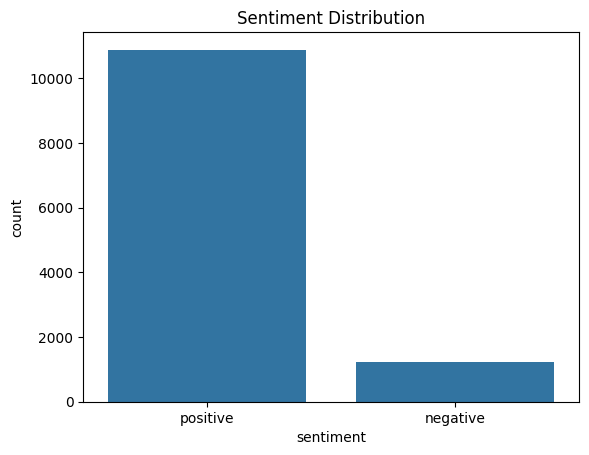

In [ ]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.85
)

X = tfidf.fit_transform(df['clean_review'])
y = df['sentiment']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC(C=1.5)
model.fit(X_train, y_train)

LinearSVC(C=1.5)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9764462809917356
              precision    recall  f1-score   support

    negative       0.93      0.83      0.88       243
    positive       0.98      0.99      0.99      2177

    accuracy                           0.98      2420
   macro avg       0.95      0.91      0.93      2420
weighted avg       0.98      0.98      0.98      2420



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9491735537190082
              precision    recall  f1-score   support

    negative       0.98      0.50      0.66       243
    positive       0.95      1.00      0.97      2177

    accuracy                           0.95      2420
   macro avg       0.97      0.75      0.82      2420
weighted avg       0.95      0.95      0.94      2420



In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9322314049586777
              precision    recall  f1-score   support

    negative       0.99      0.33      0.49       243
    positive       0.93      1.00      0.96      2177

    accuracy                           0.93      2420
   macro avg       0.96      0.66      0.73      2420
weighted avg       0.94      0.93      0.92      2420



In [ ]:
y_pred_log = log_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_svm = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    prec = precision_score(y_true, y_pred, pos_label="positive")

    rec = recall_score(y_true, y_pred, pos_label="positive")

    f1 = f1_score(y_true, y_pred, pos_label="positive")

    return [acc, prec, rec, f1]

results = {
    "Logistic": evaluate(y_test, y_pred_log),
    "NaiveBayes": evaluate(y_test, y_pred_nb),
    "SVM": evaluate(y_test, y_pred_svm)
}

results_df = pd.DataFrame(results, index=["Accuracy","Precision","Recall","F1"])
print(results_df)

           Logistic  NaiveBayes       SVM
Accuracy   0.949174    0.932231  0.976446
Precision  0.947300    0.930312  0.981381
Recall     0.999081    0.999541  0.992650
F1         0.972502    0.963685  0.986983


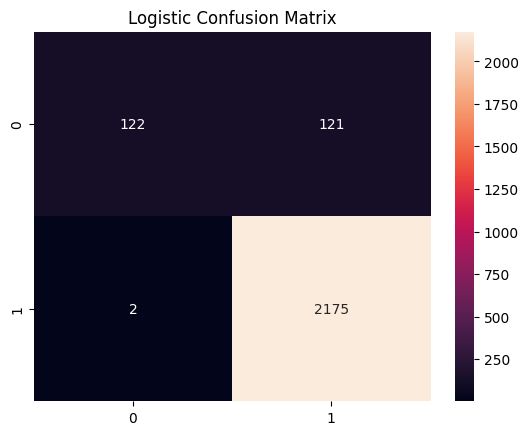

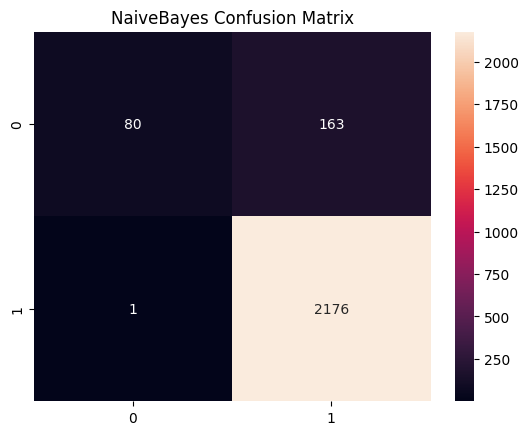

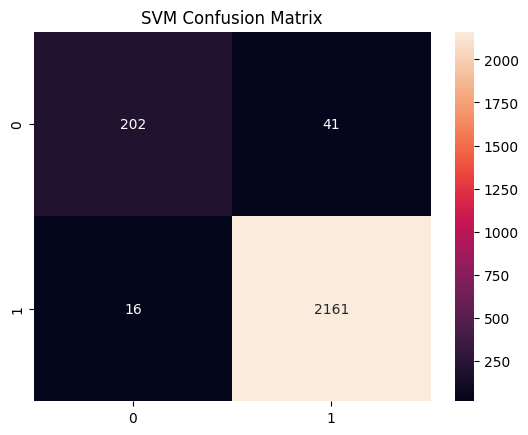

In [ ]:
from sklearn.metrics import confusion_matrix

models = {
    "Logistic": y_pred_log,
    "NaiveBayes": y_pred_nb,
    "SVM": y_pred_svm
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

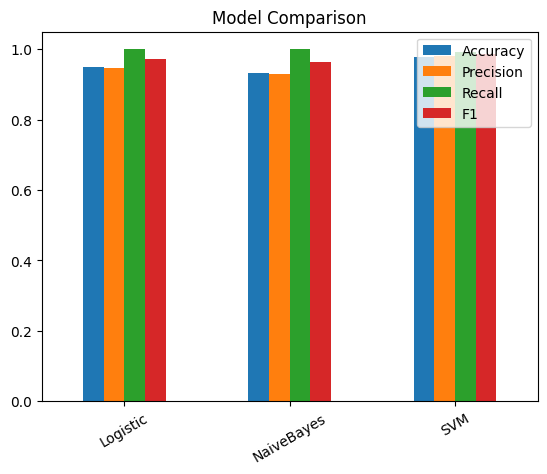

In [ ]:
results_df.T.plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import math

def calculate_all_metrics(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    TN, FP, FN, TP = cm.ravel()

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP)

    recall = TP / (TP + FN)

    f1 = 2 * (precision * recall) / (precision + recall)

    sensitivity = recall

    specificity = TN / (TN + FP)

    fpr = FP / (FP + TN)

    fnr = FN / (FN + TP)

    npv = TN / (TN + FN)

    fdr = FP / (FP + TP)

    mcc = ((TP*TN) - (FP*FN)) / math.sqrt(
        (TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)
    )

    return [
        specificity,
        sensitivity,
        accuracy,
        precision,
        f1,
        fpr,
        fnr,
        npv,
        fdr,
        mcc
    ]

In [ ]:
results = {
    "Logistic": calculate_all_metrics(y_test, y_pred_log),
    "NaiveBayes": calculate_all_metrics(y_test, y_pred_nb),
    "SVM": calculate_all_metrics(y_test, y_pred_svm)
}

metrics = [
    "Specificity",
    "Sensitivity",
    "Accuracy",
    "Precision",
    "F1",
    "FPR",
    "FNR",
    "NPV",
    "FDR",
    "MCC"
]

import pandas as pd

results_df = pd.DataFrame(results, index=metrics)

print(results_df)

             Logistic  NaiveBayes       SVM
Specificity  0.502058    0.329218  0.831276
Sensitivity  0.999081    0.999541  0.992650
Accuracy     0.949174    0.932231  0.976446
Precision    0.947300    0.930312  0.981381
F1           0.972502    0.963685  0.986983
FPR          0.497942    0.670782  0.168724
FNR          0.000919    0.000459  0.007350
NPV          0.983871    0.987654  0.926606
FDR          0.052700    0.069688  0.018619
MCC          0.683115    0.549354  0.864936


<Axes: >

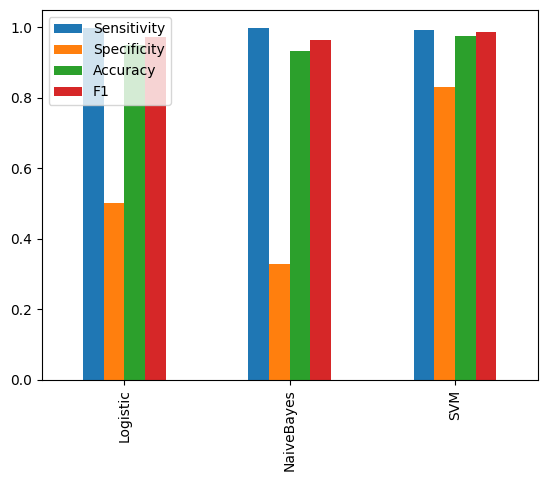

In [ ]:
results_df.loc[
["Sensitivity","Specificity","Accuracy","F1"]
].T.plot(kind="bar")

<Figure size 640x480 with 0 Axes>

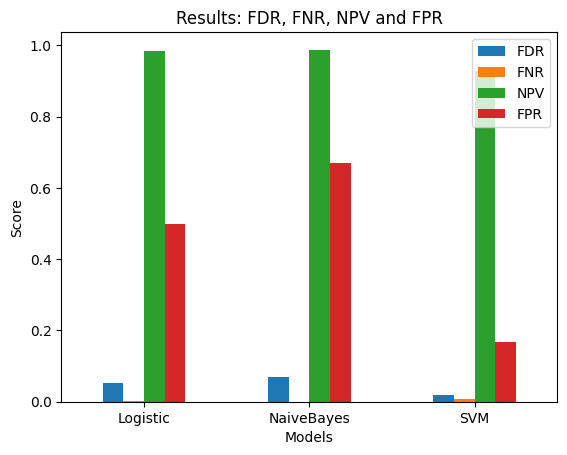

In [ ]:
plt.figure()

results_df.loc[
    ["FDR", "FNR", "NPV", "FPR"]
].T.plot(kind="bar")

plt.title(
    "Results: FDR, FNR, NPV and FPR"
)

plt.xlabel("Models")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

[0.9, 0.9566115702479339, 0.9776859504132231, 0.9756198347107438, 0.9739669421487603]


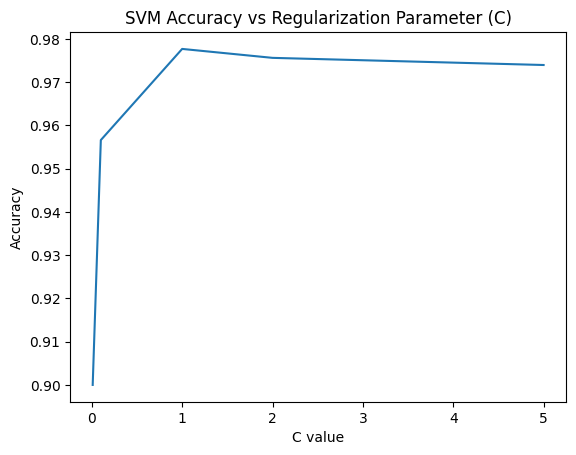

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

C_values = [0.01, 0.1, 1, 2, 5]

accuracies = []

for c in C_values:

    svm_model = LinearSVC(C=c)

    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

print(accuracies)

plt.figure()

plt.plot(C_values, accuracies)

plt.title("SVM Accuracy vs Regularization Parameter (C)")

plt.xlabel("C value")

plt.ylabel("Accuracy")

plt.show()

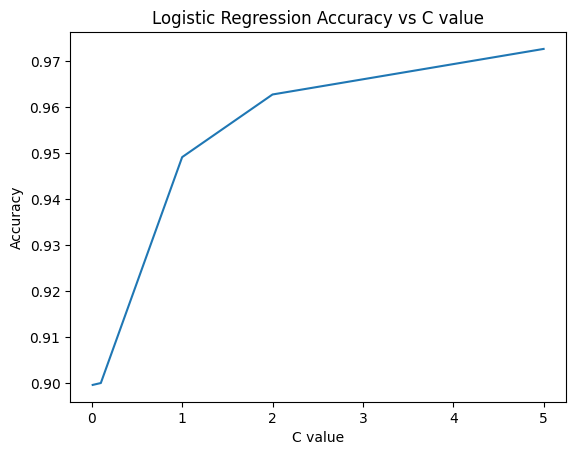

In [ ]:
from sklearn.linear_model import LogisticRegression

C_values = [0.01, 0.1, 1, 2, 5]

accuracies = []

for c in C_values:

    model = LogisticRegression(
        C=c,
        max_iter=1000
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

plt.figure()

plt.plot(C_values, accuracies)

plt.title("Logistic Regression Accuracy vs C value")

plt.xlabel("C value")

plt.ylabel("Accuracy")

plt.show()

In [ ]:
from collections import Counter

neg_text = " ".join(df[df['sentiment']=="negative"]['clean_review'])
pos_text = " ".join(df[df['sentiment']=="positive"]['clean_review'])

print("Top Complaints:", Counter(neg_text.split()).most_common(10))
print("Top Positive:", Counter(pos_text.split()).most_common(10))

Top Complaints: [('cream', 614), ('cake', 574), ('like', 551), ('ice', 535), ('one', 494), ('place', 479), ('get', 402), ('would', 387), ('time', 374), ('back', 373)]
Top Positive: [('cream', 10526), ('ice', 9924), ('place', 5207), ('good', 3597), ('great', 3359), ('flavors', 3230), ('delicious', 3040), ('one', 3030), ('love', 3023), ('best', 2916)]


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

neg_df = df[df['sentiment'] == "negative"]

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english',
    max_features=10
)

X_neg = vectorizer.fit_transform(neg_df['clean_review'])

print("Top Complaint Phrases:")
print(vectorizer.get_feature_names_out())

Top Complaint Phrases:
['birthday cake' 'carlos bakery' 'cereal milk' 'customer service'
 'ice cream' 'las vegas' 'lobster tail' 'soft serve' 'tasted like'
 'waste time']


In [ ]:
pos_df = df[df['sentiment'] == "positive"]

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english',
    max_features=10
)

X_pos = vectorizer.fit_transform(pos_df['clean_review'])

print("Top Positive Phrases:")
print(vectorizer.get_feature_names_out())

Top Positive Phrases:
['best ice' 'cream shop' 'customer service' 'highly recommend' 'ice cream'
 'love place' 'peanut butter' 'red velvet' 'salted caramel' 'soft serve']


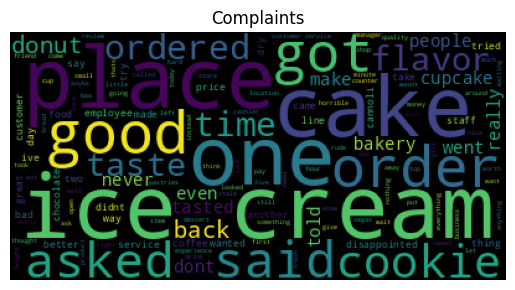

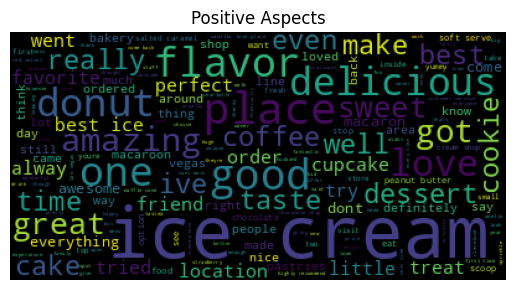

In [ ]:
from wordcloud import WordCloud

wc = WordCloud().generate(neg_text)
plt.imshow(wc)
plt.axis("off")
plt.title("Complaints")
plt.show()

wc = WordCloud().generate(pos_text)
plt.imshow(wc)
plt.axis("off")
plt.title("Positive Aspects")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bigram = CountVectorizer(ngram_range=(2,2), max_features=10)
X_bigram = bigram.fit_transform(df['clean_review'])

print("Common Phrases:", bigram.get_feature_names_out())

Common Phrases: ['best ice' 'cream shop' 'customer service' 'first time'
 'highly recommend' 'ice cream' 'ive ever' 'peanut butter'
 'salted caramel' 'soft serve']


In [ ]:
def predict_review(review_text):

    clean = clean_text(review_text)

    vector = tfidf.transform([clean])

    prediction = model.predict(vector)

    if prediction[0] == "negative":
        print(" This review is a COMPLAINT")
    else:
        print(" This review is a POSITIVE ASPECT")

In [ ]:
review = input("Enter a restaurant review: ")
predict_review(review)

Enter a restaurant review: food was amazing and staff was friendly
 This review is a POSITIVE ASPECT


In [ ]:
review = input("Enter a restaurant review: ")
predict_review(review)

Enter a restaurant review: food was not good
 This review is a COMPLAINT


In [ ]:
review = input("Enter a restaurant review: ")
predict_review(review)

Enter a restaurant review: Went here for the 1st time tonight. I ordered a turtle tornado. It was excellent. TONS of pecans and..
 This review is a POSITIVE ASPECT
